<a href="https://colab.research.google.com/github/Williamzamo/Trabajos-algebra-lineal/blob/main/caminos_en_grafos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caminos en grafos**

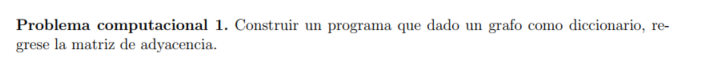

In [8]:
import numpy as np

G = {
    1: [2, 3, 4],
    2: [1, 3],
    3: [1, 2, 5],
    4: [1, 5, 6],
    5: [3, 4, 6],
    6: [4, 5],
}

def adyacencia_matrix(G):
    vertices = list(G.keys())
    n = len(vertices)
    idx = {v: i for i, v in enumerate(vertices)}
    print(idx)
    A = np.zeros((n, n), dtype=int)
    for v in vertices:
        for w in G[v]:
            i, j = idx[v], idx[w]
            A[i, j] = 1
            A[j, i] = 1
    return A, vertices
adyacencia_matrix(G)


{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}


(array([[0, 1, 1, 1, 0, 0],
        [1, 0, 1, 0, 0, 0],
        [1, 1, 0, 0, 1, 0],
        [1, 0, 0, 0, 1, 1],
        [0, 0, 1, 1, 0, 1],
        [0, 0, 0, 1, 1, 0]]),
 [1, 2, 3, 4, 5, 6])

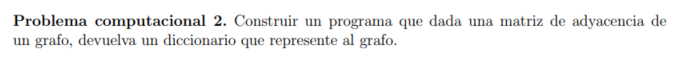

In [10]:
import numpy as np

A = np.array([[0, 1, 1, 1, 0, 0],
              [1, 0, 1, 0, 0, 0],
              [1, 1, 0, 0, 1, 0],
              [1, 0, 0, 0, 1, 1],
              [0, 0, 1, 1, 0, 1],
              [0, 0, 0, 1, 1, 0]])

def matrix_to_dic(A, vertices=None):
    n = A.shape[0]
    if vertices is None:
        vertices = list(range(n))

    G = {}
    for i in range(n):
        vecinos = [vertices[j] for j in range(n) if A[i, j] != 0]
        print(vecinos)
        G[vertices[i]] = vecinos
    return G

matrix_to_dic(A)

[1, 2, 3]
[0, 2]
[0, 1, 4]
[0, 4, 5]
[2, 3, 5]
[3, 4]


{0: [1, 2, 3], 1: [0, 2], 2: [0, 1, 4], 3: [0, 4, 5], 4: [2, 3, 5], 5: [3, 4]}

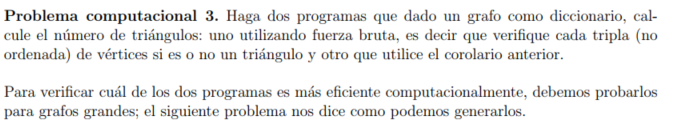

In [8]:
import numpy as np

grafo = {
    1: {2, 3},
    2: {1, 3, 4},
    3: {1, 2, 4},
    4: {2, 3, 5},
    5: {4}
}

def triangulos_fuerza_bruta(grafo):
    total = 0
    vertices = list(grafo.keys())
    n = len(vertices)

    for i in range(n):
        for j in range(i + 1, n):
            for k in range(j + 1, n):
                v1 = vertices[i]
                v2 = vertices[j]
                v3 = vertices[k]
                if v2 in grafo[v1] and v3 in grafo[v1] and v3 in grafo[v2]:
                    total += 1
    return total


def triangulos_corolario(grafo):
    vertices = list(grafo.keys())
    n = len(vertices)
    idx = {v: i for i, v in enumerate(vertices)}

    A = np.zeros((n, n), dtype=int)
    for v in grafo:
        for u in grafo[v]:
            A[idx[v]][idx[u]] = 1

    A3 = A @ A @ A
    return int(np.trace(A3) // 6)

    triangulos_fuerza_bruta(grafo)
    triangulos_corolario(grafo)

Fuerza bruta: 0
Corolario 3:  0
